In [1]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib.colors import ListedColormap

In [2]:
# 1. Load and normalize dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [3]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [6]:

# 2. Try different K values
k_values = range(1, 11)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K={k} -> Accuracy: {acc:.2f}")

K=1 -> Accuracy: 0.98
K=2 -> Accuracy: 0.98
K=3 -> Accuracy: 1.00
K=4 -> Accuracy: 0.98
K=5 -> Accuracy: 1.00
K=6 -> Accuracy: 1.00
K=7 -> Accuracy: 1.00
K=8 -> Accuracy: 1.00
K=9 -> Accuracy: 1.00
K=10 -> Accuracy: 1.00


In [7]:
# 3. Best K visualization
best_k = k_values[np.argmax(accuracies)]
print(f"\nBest K: {best_k} with Accuracy: {max(accuracies):.2f}")


Best K: 3 with Accuracy: 1.00


In [8]:
# 4. Train final model with best K
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)
y_pred_final = knn_final.predict(X_test)

In [9]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=target_names))


Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



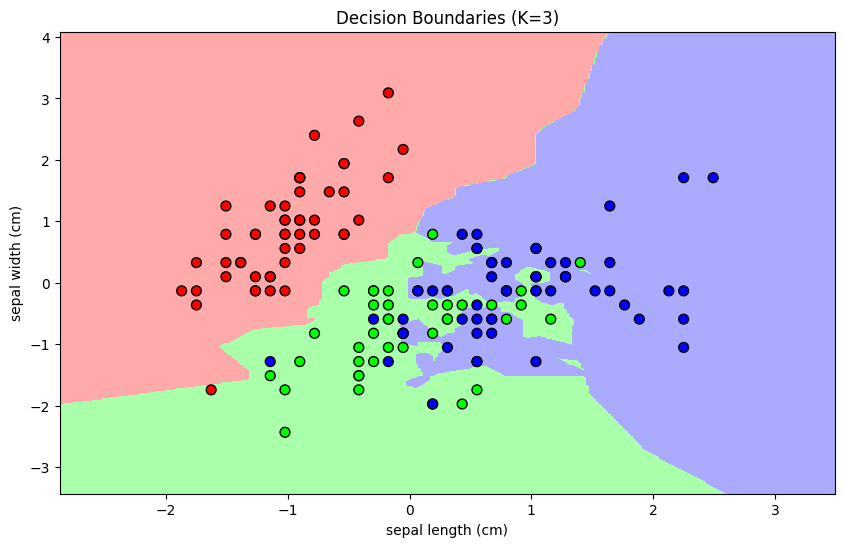

In [10]:
# 5. Visualize decision boundaries using first 2 features
def plot_decision_boundaries(X, y, k):
    X = X[:, :2]  # only first two features
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)

    h = .02  # step size in mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=50)
    plt.title(f"Decision Boundaries (K={k})")
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.savefig("decision_boundary.png")
    plt.show()

plot_decision_boundaries(X_scaled, y, best_k)